In [1]:
import os
import re
import itertools
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
import tkinter as tk
from tkinter import filedialog, simpledialog
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterable, total=None, desc=None, **kwargs):
        if total is None:
            try:
                total = len(iterable)
            except TypeError:
                total = None
        prefijo = f"{desc}: " if desc else ""
        for i, item in enumerate(iterable, start=1):
            yield item
            if total:
                pct = 100 * i / total
                print(f"\r{prefijo}{pct:5.1f}% ({i}/{total})", end="", flush=True)
        if total:
            print()


In [3]:
def extraer_datos_personalizados():
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    
    num_carpetas = simpledialog.askinteger(
        "Cantidad de carpetas",
        "¿Cuántas carpetas principales vas a seleccionar en total?",
        minvalue=1, maxvalue=10,
        parent=root
    )
    if not num_carpetas:
        root.destroy()
        return pd.DataFrame(), ""
    datos_recopilados = []
    primer_directorio = ""
    for i in range(num_carpetas):
        tipo_estrella = simpledialog.askstring(
            "Tipo de Estrella",
            f"Carpeta {i+1} de {num_carpetas}:\n¿Qué tipo de estrella contiene? (Ej: F, G, K, M)",
            parent=root
        )
        if not tipo_estrella:
            root.destroy()
            return pd.DataFrame(), ""
        tipo_estrella = tipo_estrella.upper().strip()
        directorio_raiz = filedialog.askdirectory(
            title=f"Selecciona la carpeta para los datos de estrellas {tipo_estrella}",
            parent=root
        )
        if not directorio_raiz:
            root.destroy()
            return pd.DataFrame(), ""
        if i == 0:
            primer_directorio = directorio_raiz
        print(f"\n🔍 Escaneando directorio: {directorio_raiz} (Tipo {tipo_estrella})...")
        for r, dirs, files in os.walk(directorio_raiz):
            resumen_file = None
            readme_file = None
            for file in files:
                if file.endswith(" resumen.txt") or file.endswith("_resumen.txt"):
                    resumen_file = file
                elif file.startswith("README") and file.endswith(".txt"):
                    readme_file = file
            if resumen_file and readme_file:
                nombre_planeta = os.path.basename(r).replace("_", " ")
                nombre_sistema = os.path.basename(os.path.dirname(r)).replace("_", " ")
                ruta_resumen = os.path.join(r, resumen_file)
                ruta_readme = os.path.join(r, readme_file)
                try:
                    with open(ruta_resumen, 'r', encoding='utf-8', errors='ignore') as f:
                        contenido_resumen = f.read()
                    z_est_match = re.search(r'Total estables:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                    z_inest_match = re.search(r'Total inestables:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                    z_m1_match = re.search(r'Total colisi[oó]n m1:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                    z_m2_match = re.search(r'Total colisi[oó]n m2:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                    z_est = int(z_est_match.group(1)) if z_est_match else 0
                    z_inest = int(z_inest_match.group(1)) if z_inest_match else 0
                    z_m1 = int(z_m1_match.group(1)) if z_m1_match else 0
                    z_m2 = int(z_m2_match.group(1)) if z_m2_match else 0
                    a_est_match = re.search(r'[AÁaá]rea estable:\s*([0-9.,eE+-]+)', contenido_resumen, re.IGNORECASE)
                    a_inest_match = re.search(r'[AÁaá]rea inestable:\s*([0-9.,eE+-]+)', contenido_resumen, re.IGNORECASE)
                    a_col_match = re.search(r'[AÁaá]rea.*colisi[oó]n.*m2:\s*([0-9.,eE+-]+)', contenido_resumen, re.IGNORECASE)
                    a_est = float(a_est_match.group(1).replace(',', '.')) if a_est_match else 0.0
                    a_inest = float(a_inest_match.group(1).replace(',', '.')) if a_inest_match else 0.0
                    a_col = float(a_col_match.group(1).replace(',', '.')) if a_col_match else 0.0
                    with open(ruta_readme, 'r', encoding='utf-8', errors='ignore') as f:
                        contenido_readme = f.read()
                    dist_match = re.search(r'Semi-eje mayor.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                    masa_p_match = re.search(r'Masa del Planeta.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                    masa_e_match = re.search(r'Masa de.*estrella.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                    distancia = float(dist_match.group(1).replace(',', '.')) if dist_match else 0.0
                    masa_planeta = float(masa_p_match.group(1).replace(',', '.')) if masa_p_match else 0.0
                    masa_estel = float(masa_e_match.group(1).replace(',', '.')) if masa_e_match else 1.0
                    datos_recopilados.append({
                        "Sistema": nombre_sistema,
                        "Planeta": nombre_planeta,
                        "Tipo_Estrella": tipo_estrella,
                        "Distancia_UA": distancia,
                        "Masa_Tierra": masa_planeta,
                        "Masa_Estrella": masa_estel,
                        "Num_Planetas": 0,
                        "Zonas Estables": z_est,
                        "Zonas Inestables": z_inest,
                        "Zonas Colisión m1": z_m1,
                        "Zonas Colisión m2": z_m2,
                        "Area_Estable_km2": a_est,
                        "Area_Inestable": a_inest,
                        "Area_Colision_m2": a_col
                    })
                except Exception as e:
                    print(f"❌ Error interno procesando {nombre_planeta}: {e}")
    df_resultados = pd.DataFrame(datos_recopilados)
    if not df_resultados.empty:
        df_resultados["Num_Planetas"] = df_resultados.groupby("Sistema")["Planeta"].transform("count")
        df_resultados = df_resultados.sort_values(by=["Sistema", "Planeta"]).reset_index(drop=True)
        print(f"✅ Lectura completada. Se extrajeron datos de {len(df_resultados)} planetas.")
    root.destroy()
    return df_resultados, primer_directorio

def _safe_log10(x):
    return np.log10(np.where(x > 0, x, np.nan))
def _asignar_estilos_sistema(df: pd.DataFrame) -> dict:
    if "Sistema" not in df.columns:
        df = df.copy()
        df["Sistema"] = df["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])
    sistemas_unicos = df["Sistema"].unique()
    marcadores_base = ["o", "s", "^", "D", "v", "p", "*", "h", "H", "X", "d", "P", "<", ">"]
    colores_base = plt.cm.tab20.colors
    combinaciones = itertools.product(marcadores_base, colores_base)
    estilos = {}
    for sist, (marker, color) in zip(sistemas_unicos, combinaciones):
        estilos[sist] = {"marker": marker, "color": color}
    return estilos



In [4]:
def _dibujar_panel_kde2d_hibrido(fig, ax, df_subset, titulo, estilos_sistema, xlims, ylims, es_primer_panel=False):
    resumen_panel = None
    
    if df_subset.empty:
        ax.axis("off")
        return resumen_panel
    mask_valid = (df_subset["Distancia_UA"] > 0) & (df_subset["Masa_Tierra"] > 0)
    df_valid = df_subset[mask_valid].copy()
    if df_valid.empty:
        ax.axis("off")
        return resumen_panel
    metricas_info = [
        ("Area_Estable_km2", "Stable Zones", "magma", "fill_and_line"),
        ("Area_Inestable", "Unstable Zones", "crimson", "line_only"),            
        ("Zonas Colisión m1", "Collision m1 (Star)", "springgreen", "line_only"), 
        ("Area_Colision_m2", "Collision m2 (Planet)", "darkviolet", "line_only"), 
    ]
    for metrica, label_str, color_principal, plot_type in metricas_info:
        if metrica not in df_valid.columns: 
            continue
            
        mask_metrica = df_valid[metrica] > 0
        df_metrica = df_valid[mask_metrica]
        
        if len(df_metrica) >= 4:
            x_m = np.log10(df_metrica["Distancia_UA"].values)
            y_m = np.log10(df_metrica["Masa_Tierra"].values)
            weights = _safe_log10(df_metrica[metrica].values)
            
            mask_w = ~np.isnan(weights)
            x_m, y_m, weights = x_m[mask_w], y_m[mask_w], weights[mask_w]
            
            if x_m.var() > 0 and y_m.var() > 0 and np.sum(weights) > 0:
                try:
                    xy = np.vstack([x_m, y_m])
                    kde = gaussian_kde(xy, weights=weights, bw_method=0.6)
                    X, Y = np.mgrid[xlims[0]:xlims[1]:150j, ylims[0]:ylims[1]:150j]
                    positions = np.vstack([X.ravel(), Y.ravel()])
                    Z = np.reshape(kde(positions).T, X.shape)
                    
                    z_max = Z.max()
                    if z_max > 0:
                        Z = (Z / z_max) * 100.0  # Normalizar a 100%
                    
                    Z_flat = Z.flatten()
                    if plot_type == "fill_and_line":
                        # 1. Forzar el Color de Fondo
                        ax.set_facecolor(plt.cm.magma(0))
                        
                        # 2. Relleno desde Cero Absoluto (50 niveles)
                        niveles_fill = np.linspace(0, np.max(Z), 50)
                        contour = ax.contourf(X, Y, Z, levels=niveles_fill, cmap="magma", extend='min', alpha=0.9, zorder=1)
                        
                        ax.contour(X, Y, Z, levels=[15.0], colors=['#d4af37'], linewidths=1.5, zorder=2)
                        
                        # Anotaciones
                        niveles_anotacion = np.linspace(15.0, 100.0, 4)
                        print(f"\n--- Extracción de a_max por Niveles ({label_str} | {titulo}) ---")
                        for idx, nivel in enumerate(niveles_anotacion):
                            mask_nivel = Z >= nivel
                            if np.any(mask_nivel):
                                x_max_nivel = np.max(X[mask_nivel])
                                a_max_ua = 10 ** x_max_nivel
                                
                                idx_x = np.where((X == x_max_nivel) & mask_nivel)[0][0]
                                idx_y = np.where((X == x_max_nivel) & mask_nivel)[1][0]
                                y_max_nivel = Y[idx_x, idx_y]
                                
                                print(f"Densidad >= {nivel:.1f}%: a_max = {a_max_ua:.2f} UA")
                                
                                ax.text(x_max_nivel + 0.03, y_max_nivel, f"{a_max_ua:.2f} UA",
                                        color="black", fontsize=9, fontweight="bold", zorder=8,
                                        ha="left", va="center",
                                        bbox=dict(facecolor="white", alpha=0.8, edgecolor="#d4af37", boxstyle="round,pad=0.2"))
                        
                        resumen_panel = contour
                    else:
                        min_val = max(np.percentile(Z_flat, 40), 10.0)
                        max_val = np.percentile(Z_flat, 95)
                        if max_val > min_val:
                            niveles = np.linspace(min_val, max_val, 4)
                            ax.contour(X, Y, Z, levels=niveles, colors=[color_principal], linewidths=2.5, zorder=3)
                except np.linalg.LinAlgError:
                    pass
    for sist in df_valid["Sistema"].unique():
        df_sist = df_valid[df_valid["Sistema"] == sist]
        props = estilos_sistema.get(sist, {"marker": "o", "color": "white"})
        ax.scatter(np.log10(df_sist["Distancia_UA"]),
                   np.log10(df_sist["Masa_Tierra"]),
                   marker=props["marker"], color=props["color"],
                   s=110, edgecolor="white", linewidth=1.0,
                   label=sist, zorder=4)
    
    ax.scatter(0, 0, marker='o', s=300, color='dodgerblue', edgecolor='white', linewidth=1.5, label="Earth", zorder=5, clip_on=False)
    ax.text(0, -0.15, "Earth", ha='center', va='top', fontsize=12, fontweight='bold', color='dodgerblue', zorder=5)
    log_dist_jup = np.log10(5.2)
    log_mass_jup = np.log10(318.0)
    ax.scatter(log_dist_jup, log_mass_jup, marker='o', s=450, color='peru', edgecolor='white', linewidth=1.5, label="Jupiter", zorder=5, clip_on=False)
    ax.text(log_dist_jup, log_mass_jup - 0.15, "Jupiter", ha='center', va='top', fontsize=12, fontweight='bold', color='peru', zorder=5)
    # --- LÍMITES DINÁMICOS AMPLIADOS ---
    x_min, x_max = xlims
    y_min, y_max = ylims
    
    x_max_dinamico = max(x_max, 0.85)
    x_min_dinamico = min(x_min, -0.2)
    y_max_dinamico = max(y_max, 2.7) 
    y_min_dinamico = min(y_min, -0.5)
    ax.set_xlim(x_min_dinamico, x_max_dinamico)
    ax.set_ylim(y_min_dinamico, y_max_dinamico)
    
    ax.set_aspect('auto')
    ax.set_xlabel("log[Distance] (AU)", fontsize=16) 
    if es_primer_panel:
        ax.set_ylabel(r"log[Planetary Mass] ($M_\oplus$)", fontsize=16)
    
    # 3. Actualización de la Cuadrícula
    ax.grid(True, linestyle=':', color='white', alpha=0.2, zorder=0)
    return resumen_panel

In [6]:
N_BOOTSTRAP_INCERTIDUMBRE = 1000  # Convergencia estadística garantizada
BOOTSTRAP_GRID_RES = 150j

In [10]:
def _calcular_limites_criticos(Z: np.ndarray, X: np.ndarray, umbral_minimo: float):
    Z_flat = Z.flatten()
    idx_max = np.argmax(Z_flat)
    pico_log = X.flatten()[idx_max]
    
    indices_alta_densidad = np.where(Z >= umbral_minimo)
    x_alta_densidad = X[indices_alta_densidad]
    
    if len(x_alta_densidad) == 0:
        return None, None
        
    max_log = float(np.max(x_alta_densidad))
    return pico_log, max_log
def _bootstrap_limites_criticos(x, y, weights, xlims, ylims, umbral_minimo, n_bootstrap=N_BOOTSTRAP_INCERTIDUMBRE, grid_res=BOOTSTRAP_GRID_RES):
    rng = np.random.default_rng()
    n = len(x)
    pico_boot_log, max_boot_log = [], []

    Xb, Yb = np.mgrid[xlims[0]:xlims[1]:grid_res, ylims[0]:ylims[1]:grid_res]
    positions_b = np.vstack([Xb.ravel(), Yb.ravel()])

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        x_b, y_b, w_b = x[idx], y[idx], weights[idx]

        if x_b.var() == 0 or y_b.var() == 0:
            continue
        try:
            kde_b = gaussian_kde(np.vstack([x_b, y_b]), weights=w_b, bw_method=0.6)
            Z_b = np.reshape(kde_b(positions_b).T, Xb.shape)
            
            # ---> SOLUCIÓN: NORMALIZAR AL 100% IGUAL QUE EN EL GRÁFICO PRINCIPAL <---
            z_max_b = Z_b.max()
            if z_max_b > 0:
                Z_b = (Z_b / z_max_b) * 100.0
                
        except np.linalg.LinAlgError:
            continue

        pico_l, max_l = _calcular_limites_criticos(Z_b, Xb, umbral_minimo)
        if pico_l is not None:
            pico_boot_log.append(pico_l)
            max_boot_log.append(max_l)

    return pico_boot_log, max_boot_log

def _dibujar_panel_kde2d_hibrido(fig, ax, df_subset, titulo, estilos_sistema, xlims, ylims, es_primer_panel=False):
    resumen_panel = {"titulo": titulo, "metricas": {}}
    contour_obj = None 
    
    if df_subset.empty:
        ax.set_title(f"{titulo}\n(N=0)", fontsize=16, fontweight="bold", pad=15)
        ax.axis("off")
        return resumen_panel, contour_obj
    mask_valid = (df_subset["Distancia_UA"] > 0) & (df_subset["Masa_Tierra"] > 0)
    df_valid = df_subset[mask_valid].copy()
    if df_valid.empty:
        ax.set_title(f"{titulo}\n(N=0 válidos)", fontsize=16, fontweight="bold", pad=15)
        ax.axis("off")
        return resumen_panel, contour_obj
    n_planetas = len(df_valid)
    # --- LÍNEAS DE CONTORNO MUY DISTINTAS ---
    metricas_info = [
        ("Area_Estable_km2", "Stable Zones", "gold", "fill_and_line"),
        ("Area_Inestable", "Unstable Zones", "cyan", "line_only"),
        ("Zonas Colisión m1", "Collision m1 (Star)", "lime", "line_only"),
        ("Area_Colision_m2", "Collision m2 (Planet)", "dodgerblue", "line_only"),
    ]
    for metrica, label_str, color_principal, plot_type in metricas_info:
        if metrica not in df_valid.columns: 
            continue
            
        mask_metrica = df_valid[metrica] > 0
        df_metrica = df_valid[mask_metrica]
        
        if len(df_metrica) >= 4:
            x_m = np.log10(df_metrica["Distancia_UA"].values)
            y_m = np.log10(df_metrica["Masa_Tierra"].values)
            weights = _safe_log10(df_metrica[metrica].values)
            
            if x_m.var() > 0 and y_m.var() > 0 and np.sum(weights) > 0:
                try:
                    xy = np.vstack([x_m, y_m])
                    kde = gaussian_kde(xy, weights=weights, bw_method=0.6)
                    X, Y = np.mgrid[xlims[0]:xlims[1]:150j, ylims[0]:ylims[1]:150j]
                    positions = np.vstack([X.ravel(), Y.ravel()])
                    Z = np.reshape(kde(positions).T, X.shape)
                    
                    z_max = Z.max()
                    if z_max > 0:
                        Z = (Z / z_max) * 100.0
                    Z_flat = Z.flatten()
                    if plot_type == "fill_and_line":
                        # --- COLORES EXACTOS SOLICITADOS ---
                        custom_levels = [0, 15.0, 36.25, 57.50, 78.75, 100.0]
                        custom_colors = ['#050505', 'purple', 'hotpink', 'darkorange', 'gold']
                        
                        contour = ax.contourf(X, Y, Z, levels=custom_levels, colors=custom_colors, extend='neither', alpha=0.9, zorder=1)
                        ax.contour(X, Y, Z, levels=[15.0], colors=[color_principal], linewidths=2.5, zorder=2)
                        
                        contour_obj = contour
                        umbral_minimo = 15.0
                    else:
                        min_val = max(np.percentile(Z_flat, 40), 10.0) 
                        max_val = np.percentile(Z_flat, 95)
                        if max_val > min_val:
                            niveles = np.linspace(min_val, max_val, 4)
                            ax.contour(X, Y, Z, levels=niveles, colors=[color_principal], linewidths=2.5, zorder=2)
                            umbral_minimo = niveles[0]
                        else:
                            umbral_minimo = None
                    # --- EXTRACCIÓN DE DATOS PARA *TODAS* LAS REGIONES ---
                    if umbral_minimo is not None:
                        pico_log, max_log = _calcular_limites_criticos(Z, X, umbral_minimo)
                        
                        if pico_log is not None:
                            pico_au = 10 ** pico_log
                            max_au = 10 ** max_log
                            
                            pico_boot_log, max_boot_log = _bootstrap_limites_criticos(x_m, y_m, weights, xlims, ylims, umbral_minimo)
                            
                            if len(pico_boot_log) >= 5:
                                pico_boot_au = 10 ** np.array(pico_boot_log)
                                max_boot_au = 10 ** np.array(max_boot_log)
                                p16_pico, p84_pico = np.percentile(pico_boot_au, 16), np.percentile(pico_boot_au, 84)
                                p16_max, p84_max = np.percentile(max_boot_au, 16), np.percentile(max_boot_au, 84)
                                sigma_pico_au = (p84_pico - p16_pico) / 2.0
                                sigma_max_au = (p84_max - p16_max) / 2.0
                            else:
                                sigma_pico_au = 0.0
                                sigma_max_au = 0.0
                                
                            resumen_panel["metricas"][metrica] = {
                                "label": label_str,
                                "opt_au": pico_au, "opt_err": sigma_pico_au,
                                "max_au": max_au, "max_err": sigma_max_au
                            }
                            
                            # --- GRAFICAR ANOTACIONES VISUALES SÓLO PARA LA ESTABILIDAD ---
                            if metrica == "Area_Estable_km2":
                                if sigma_max_au > 0:
                                    texto_opt = f"$a_{{min}}= {pico_au:.2f} \\pm {sigma_pico_au:.2f}$ AU"
                                    texto_max = f"$a_{{max}}= {max_au:.2f} \\pm {sigma_max_au:.2f}$ AU"
                                else:
                                    texto_opt = f"$a_{{min}}= {pico_au:.2f}$ AU"
                                    texto_max = f"$a_{{max}}= {max_au:.2f}$ AU"
                                
                                rango_y = ylims[1] - ylims[0]
                                rango_x = xlims[1] - xlims[0]
                                offset = rango_x * 0.015
                                
                                ha_pico = "left" if pico_log < (xlims[0]+xlims[1])/2 else "right"
                                ha_max = "left" if max_log < (xlims[0]+xlims[1])/2 else "right"
                                offset_pico = offset if ha_pico == "left" else -offset
                                offset_max = offset if ha_max == "left" else -offset
                                
                                ax.axvline(x=pico_log, color="gold", linestyle="--", linewidth=2.5, zorder=6)
                                ax.axvline(x=max_log, color="lightgray", linestyle="-.", linewidth=2.5, zorder=6, alpha=0.95)
                                
                                ax.text(pico_log + offset_pico, ylims[1] - rango_y * 0.05, texto_opt,
                                        color="black", fontsize=11, fontweight="bold", zorder=7, ha=ha_pico, va="top",
                                        bbox=dict(facecolor="gold", alpha=0.9, edgecolor="gray", boxstyle="round,pad=0.3"))
                                
                                ax.text(max_log + offset_max, ylims[1] - rango_y * 0.15, texto_max,
                                        color="black", fontsize=11, fontweight="bold", zorder=7, ha=ha_max, va="top",
                                        bbox=dict(facecolor="lightgray", alpha=0.9, edgecolor="gray", boxstyle="round,pad=0.3"))
                except np.linalg.LinAlgError:
                    pass
    for sist in df_valid["Sistema"].unique():
        df_sist = df_valid[df_valid["Sistema"] == sist]
        props = estilos_sistema.get(sist, {"marker": "o", "color": "white"})
        ax.scatter(np.log10(df_sist["Distancia_UA"]),
                   np.log10(df_sist["Masa_Tierra"]),
                   marker=props["marker"], color=props["color"],
                   s=110, edgecolor="white", linewidth=1.0,
                   label=sist, zorder=3)
    
    ax.scatter(0, 0, marker='o', s=300, color='dodgerblue', edgecolor='white', linewidth=1.5, label="Earth", zorder=4, clip_on=False)
    ax.text(0, -0.15, "Earth", ha='center', va='top', fontsize=12, fontweight='bold', color='dodgerblue', zorder=4)
    log_dist_jup = np.log10(5.2)
    log_mass_jup = np.log10(318.0)
    ax.scatter(log_dist_jup, log_mass_jup, marker='o', s=450, color='peru', edgecolor='white', linewidth=1.5, label="Jupiter", zorder=4, clip_on=False)
    ax.text(log_dist_jup, log_mass_jup - 0.15, "Jupiter", ha='center', va='top', fontsize=12, fontweight='bold', color='peru', zorder=4)
    ax.set_title(f"{titulo}\n(N={n_planetas} planetas)", fontsize=18, fontweight="bold", pad=15)
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_box_aspect(1) 
    
    ax.set_xlabel("log[Distance] (AU)", fontsize=16) 
    if es_primer_panel:
        ax.set_ylabel(r"log[Planetary Mass] ($M_\oplus$)", fontsize=16)
    
    # Cuadrícula semi-transparente sobre el fondo negro/colores
    ax.grid(True, which="both", ls="--", color="white", alpha=0.15, zorder=3)
    return resumen_panel, contour_obj
def plot_islands_kde2d_combinado(df: pd.DataFrame, base_dir: str, tipos=("F", "G", "K", "M")):
    print(f"\nGenerando Mapas de Contornos 2D KDE Híbridos y Análisis Estadístico...")
    df = df.copy()
    if "Sistema" not in df.columns:
        df["Sistema"] = df["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])
    
    df["Tipo_Estrella"] = df["Tipo_Estrella"].astype(str).str.upper().str.strip()
    def _asignar_estilos_sistema(df: pd.DataFrame) -> dict:
        sistemas_unicos = df["Sistema"].unique()
        marcadores_base = ["o", "s", "^", "D", "v", "p", "*", "h", "H", "X", "d", "P", "<", ">"]
        colores_base = plt.cm.tab20.colors
        combinaciones = itertools.product(marcadores_base, colores_base)
        estilos = {}
        for sist, (marker, color) in zip(sistemas_unicos, combinaciones):
            estilos[sist] = {"marker": marker, "color": color}
        return estilos
    
    estilos_sistema = _asignar_estilos_sistema(df)
    
    dist_pos = df["Distancia_UA"][df["Distancia_UA"] > 0]
    masa_pos = df["Masa_Tierra"][df["Masa_Tierra"] > 0]
    
    if dist_pos.empty or masa_pos.empty:
        print("No hay datos válidos para graficar.")
        return
    x_all = np.log10(dist_pos.values)
    y_all = np.log10(masa_pos.values)
    
    margen_x = (x_all.max() - x_all.min()) * 0.1
    xlims = (x_all.min() - margen_x, x_all.max() + margen_x)
    min_y_req = min(y_all.min() - 0.4, -0.5)
    max_y_req = max(y_all.max() + 0.4, 2.8)
    ylims = (min_y_req, max_y_req)
    num_paneles = len(tipos)
    
    fig, axes = plt.subplots(1, num_paneles, figsize=(8 * num_paneles, 12))
    fig.subplots_adjust(bottom=0.45, right=0.90, wspace=0.15)
    
    if num_paneles == 1:
        axes = [axes]
    tareas_paneles = [
        (axes[i], df[df["Tipo_Estrella"] == tipo].copy(), f"Type {tipo}")
        for i, tipo in enumerate(tipos)
    ]
    
    resumenes = []
    contour_para_colorbar = None
    
    for ax, df_subset, titulo in tqdm(tareas_paneles, desc="Generando paneles 2D híbridos", unit="panel"):
        res, contour = _dibujar_panel_kde2d_hibrido(fig, ax, df_subset, titulo, estilos_sistema, xlims, ylims, es_primer_panel=(ax is axes[0]))
        if res:
            resumenes.append(res)
        if contour is not None:
            contour_para_colorbar = contour
    if contour_para_colorbar is not None:
        cbar = fig.colorbar(contour_para_colorbar, ax=axes, pad=0.02, aspect=30, extend='neither')
        cbar.set_label('Relative Probability Density (%)', fontsize=14, fontweight='bold')
    # --- IMPRESIÓN DEL RESUMEN DE TODAS LAS REGIONES ---
    print("\n" + "="*95)
    print("🎯 RESUMEN DE PROBABILIDAD ORBITAL Y LÍMITES MÁXIMOS")
    print("="*95)
    for res in resumenes:
        nombre_estrella = res["titulo"].replace("Type", "Estrella Tipo")
        print(f"\n[{nombre_estrella}]")
        for metrica, datos in res["metricas"].items():
            print(f"  - {datos['label']:<22} -> Límite Máx (a_max): {datos['max_au']:6.2f} ± {datos['max_err']:.2f} AU")
            if metrica == "Area_Estable_km2":
                print(f"  - {'Óptimo (Pico)':<22} -> Distancia (a_min): {datos['opt_au']:6.2f} ± {datos['opt_err']:.2f} AU")
    print("="*95 + "\n")
    
    handles_global = []
    labels_global = []
    
    leyenda_base = [
        ("Stable Zones", "gold", "fill_and_line"),
        ("Unstable Zones", "cyan", "line_only"),
        ("Collision m1 (Star)", "lime", "line_only"),
        ("Collision m2 (Planet)", "dodgerblue", "line_only"),
    ]
    
    for label, color, plot_type in leyenda_base:
        if plot_type == "fill_and_line":
            patch = mpatches.Patch(facecolor="darkorange", edgecolor=color, linewidth=2, label=label)
            handles_global.append(patch)
        else:
            line = Line2D([0], [0], color=color, linewidth=2.5, label=label)
            handles_global.append(line)
        labels_global.append(label)
    
    for ax in axes:
        h_ax, l_ax = ax.get_legend_handles_labels()
        for h, l in zip(h_ax, l_ax):
            if l not in labels_global:
                labels_global.append(l)
                handles_global.append(h)
    
    if labels_global:
        fig.legend(handles_global, labels_global, loc="upper center", bbox_to_anchor=(0.5, 0.40),
                   ncol=min(8, len(labels_global)), frameon=True, shadow=True, fontsize=11, title="Global Legend", title_fontsize=14)
                   
    ruta_pdf = os.path.join(base_dir, f"Map_2D_KDE_Hybrid_PorTipoEstrella.pdf")
    plt.savefig(ruta_pdf, format="pdf", dpi=300, bbox_inches="tight")
    
    print(f"\nGráfico vectorial guardado exitosamente en: {ruta_pdf}")
    plt.show()
    plt.close(fig)
def _safe_log10(x):
    return np.log10(np.asarray(x, dtype=float) + 1.0)
def extraer_datos_personalizados():
    num_carpetas = simpledialog.askinteger(
        "Cantidad de carpetas",
        "¿Cuántas carpetas principales vas a seleccionar en total?",
        minvalue=1, maxvalue=10
    )
    if not num_carpetas:
        return pd.DataFrame(), ""
    datos_recopilados = []
    primer_directorio = ""
    for i in range(num_carpetas):
        tipo_estrella = simpledialog.askstring(
            "Tipo de Estrella",
            f"Carpeta {i+1} de {num_carpetas}:\n¿Qué tipo de estrella contiene? (Ej: F, G, K, M)"
        )
        if not tipo_estrella:
            return pd.DataFrame(), ""
        tipo_estrella = tipo_estrella.upper().strip()
        directorio_raiz = filedialog.askdirectory(
            title=f"Selecciona la carpeta para los datos de estrellas {tipo_estrella}"
        )
        if not directorio_raiz:
            return pd.DataFrame(), ""
        if i == 0:
            primer_directorio = directorio_raiz
        print(f"\n🔍 Escaneando directorio: {directorio_raiz} (Tipo {tipo_estrella})...")
        for root, dirs, files in os.walk(directorio_raiz):
            resumen_file = None
            readme_file = None
            for file in files:
                if file.endswith(" resumen.txt") or file.endswith("_resumen.txt"):
                    resumen_file = file
                elif file.startswith("README") and file.endswith(".txt"):
                    readme_file = file
            if resumen_file and readme_file:
                nombre_planeta = os.path.basename(root).replace("_", " ")
                nombre_sistema = os.path.basename(os.path.dirname(root)).replace("_", " ")
                ruta_resumen = os.path.join(root, resumen_file)
                ruta_readme = os.path.join(root, readme_file)
                try:
                    with open(ruta_resumen, 'r', encoding='utf-8', errors='ignore') as f:
                        contenido_resumen = f.read()
                    z_est_match = re.search(r'Total estables:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                    z_inest_match = re.search(r'Total inestables:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                    z_m1_match = re.search(r'Total colisi[oó]n m1:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                    z_m2_match = re.search(r'Total colisi[oó]n m2:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                    z_est = int(z_est_match.group(1)) if z_est_match else 0
                    z_inest = int(z_inest_match.group(1)) if z_inest_match else 0
                    z_m1 = int(z_m1_match.group(1)) if z_m1_match else 0
                    z_m2 = int(z_m2_match.group(1)) if z_m2_match else 0
                    a_est_match = re.search(r'[AÁaá]rea estable:\s*([0-9.,eE+-]+)', contenido_resumen, re.IGNORECASE)
                    a_inest_match = re.search(r'[AÁaá]rea inestable:\s*([0-9.,eE+-]+)', contenido_resumen, re.IGNORECASE)
                    a_col_match = re.search(r'[AÁaá]rea.*colisi[oó]n.*m2:\s*([0-9.,eE+-]+)', contenido_resumen, re.IGNORECASE)
                    a_est = float(a_est_match.group(1).replace(',', '.')) if a_est_match else 0.0
                    a_inest = float(a_inest_match.group(1).replace(',', '.')) if a_inest_match else 0.0
                    a_col = float(a_col_match.group(1).replace(',', '.')) if a_col_match else 0.0
                    with open(ruta_readme, 'r', encoding='utf-8', errors='ignore') as f:
                        contenido_readme = f.read()
                    dist_match = re.search(r'Semi-eje mayor.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                    masa_p_match = re.search(r'Masa del Planeta.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                    masa_e_match = re.search(r'Masa de.*estrella.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                    distancia = float(dist_match.group(1).replace(',', '.')) if dist_match else 0.0
                    masa_planeta = float(masa_p_match.group(1).replace(',', '.')) if masa_p_match else 0.0
                    masa_estel = float(masa_e_match.group(1).replace(',', '.')) if masa_e_match else 1.0
                    datos_recopilados.append({
                        "Sistema": nombre_sistema,
                        "Planeta": nombre_planeta,
                        "Tipo_Estrella": tipo_estrella,
                        "Distancia_UA": distancia,
                        "Masa_Tierra": masa_planeta,
                        "Masa_Estrella": masa_estel,
                        "Num_Planetas": 0,
                        "Zonas Estables": z_est,
                        "Zonas Inestables": z_inest,
                        "Zonas Colisión m1": z_m1,
                        "Zonas Colisión m2": z_m2,
                        "Area_Estable_km2": a_est,
                        "Area_Inestable": a_inest,
                        "Area_Colision_m2": a_col
                    })
                except Exception as e:
                    print(f"❌ Error interno procesando {nombre_planeta}: {e}")
    df_resultados = pd.DataFrame(datos_recopilados)
    if not df_resultados.empty:
        df_resultados["Num_Planetas"] = df_resultados.groupby("Sistema")["Planeta"].transform("count")
        df_resultados = df_resultados.sort_values(by=["Sistema", "Planeta"]).reset_index(drop=True)
        print(f"✅ Lectura completada. Se extrajeron datos de {len(df_resultados)} planetas.")
    return df_resultados, primer_directorio


In [12]:
def plot_islands_por_multiplicidad(df: pd.DataFrame, base_dir: str):
    print(f"\nGenerando Mapas de Contornos 2D KDE Híbridos por Multiplicidad...")
    df = df.copy()
    if "Sistema" not in df.columns:
        df["Sistema"] = df["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])
    
    df["Tipo_Estrella"] = df["Tipo_Estrella"].astype(str).str.upper().str.strip()
    estilos_sistema = _asignar_estilos_sistema(df)
    
    dist_pos = df["Distancia_UA"][df["Distancia_UA"] > 0]
    masa_pos = df["Masa_Tierra"][df["Masa_Tierra"] > 0]
    
    if dist_pos.empty or masa_pos.empty:
        print("No hay datos válidos para graficar.")
        return
        
    x_all = np.log10(dist_pos.values)
    y_all = np.log10(masa_pos.values)
    
    margen_x = (x_all.max() - x_all.min()) * 0.1
    xlims = (x_all.min() - margen_x, x_all.max() + margen_x)
    min_y_req = min(y_all.min() - 0.4, -0.5)
    max_y_req = max(y_all.max() + 0.4, 2.8)
    ylims = (min_y_req, max_y_req)
    
    multiplicidades = sorted(df["Num_Planetas"].unique())
    num_paneles = len(multiplicidades)
    
    fig, axes = plt.subplots(1, num_paneles, figsize=(7 * num_paneles, 12))
    fig.subplots_adjust(bottom=0.35, right=0.90, wspace=0.15)
    
    tipo_estrella = df["Tipo_Estrella"].iloc[0] if not df.empty else ""
    fig.suptitle(f"2D KDE Contour Maps by Stellar Type {tipo_estrella}", fontsize=28, fontweight="bold")
    
    if num_paneles == 1:
        axes = [axes]
        
    tareas_paneles = [
        (axes[i], df[df["Num_Planetas"] == num].copy(), f"{num}-Planet Systems")
        for i, num in enumerate(multiplicidades)
    ]
    
    resumenes = []
    global_contour = None
    
    try:
        from tqdm import tqdm
        iterable_paneles = tqdm(tareas_paneles, desc="Generando paneles 2D", unit="panel")
    except ImportError:
        iterable_paneles = tareas_paneles
        
    for ax, df_subset, titulo in iterable_paneles:
        res, c_fill = _dibujar_panel_kde2d_hibrido(fig, ax, df_subset, titulo, estilos_sistema, xlims, ylims, es_primer_panel=(ax is axes[0]))
        if res:
            resumenes.append(res)
        if c_fill is not None and global_contour is None:
            global_contour = c_fill
            
    # ====== NUEVO BUCLE DE IMPRESIÓN ADAPTADO A LA PALETA ======
    print("\n" + "="*95)
    print("🎯 RESUMEN DE PROBABILIDAD ORBITAL Y LÍMITES MÁXIMOS")
    print("="*95)
    for res in resumenes:
        if not res or "metricas" not in res:
            continue
            
        print(f"[{res['titulo']}]")
        
        metrica_estable = res["metricas"].get("Area_Estable_km2", {})
        
        opt_au = metrica_estable.get("opt_au", np.nan)
        opt_err = metrica_estable.get("opt_err", 0.0)
        morada_err = metrica_estable.get("max_err", 0.0)
        
        zonas = metrica_estable.get("zonas_max_au", {})
        amarilla = zonas.get("gold", np.nan)
        naranja = zonas.get("darkorange", np.nan)
        rosada = zonas.get("hotpink", np.nan)
        morada = zonas.get("purple", np.nan)
        
        print(f"  - Óptimo (Pico)          -> Distancia (a_min): {opt_au:6.2f} ± {opt_err:.2f} AU")
        print(f"  - Zona Amarilla (>78.7%) -> Límite Máx (a_max): {amarilla:6.2f} AU")
        print(f"  - Zona Naranja  (>57.5%) -> Límite Máx (a_max): {naranja:6.2f} AU")
        print(f"  - Zona Rosada   (>36.2%) -> Límite Máx (a_max): {rosada:6.2f} AU")
        print(f"  - Zona Morada   (>15.0%) -> Límite Máx (a_max): {morada:6.2f} ± {morada_err:.2f} AU")
        
        nombres_otras = {
            "Area_Inestable": "Unstable Zones",
            "Zonas Colisión m1": "Collision m1 (Star)",
            "Area_Colision_m2": "Collision m2 (Planet)"
        }
        
        for clave, nombre_print in nombres_otras.items():
            if clave in res["metricas"]:
                val_max = res["metricas"][clave].get("max_au", np.nan)
                val_err = res["metricas"][clave].get("max_err", 0.0)
                print(f"  - {nombre_print:<22} -> Límite Máx (a_max): {val_max:6.2f} ± {val_err:.2f} AU")
                
        print("-" * 60)
    print("="*95 + "\n")
    # ==========================================================
    
    if global_contour is not None:
        cbar_ax = fig.add_axes([0.92, 0.40, 0.015, 0.45])
        cbar = fig.colorbar(global_contour, cax=cbar_ax)
        cbar.set_label("Relative Probability Density (%)", fontsize=16, fontweight="bold")
        cbar.ax.tick_params(labelsize=14)
    
    handles_global = []
    labels_global = []
    
    leyenda_base = [
        ("Stable Zones", "gold", "fill_and_line"),
        ("Unstable Zones", "cyan", "line_only"),
        ("Collision m1 (Star)", "limegreen", "line_only"),
        ("Collision m2 (Planet)", "dodgerblue", "line_only"),
    ]
    
    for label, color, plot_type in leyenda_base:
        if plot_type == "fill_and_line":
            patch = mpatches.Patch(facecolor=plt.get_cmap("magma")(0.8), edgecolor=color, linewidth=2.5, label=label)
            handles_global.append(patch)
        else:
            line = Line2D([0], [0], color=color, linewidth=2.5, label=label)
            handles_global.append(line)
        labels_global.append(label)
    
    for ax in axes:
        h_ax, l_ax = ax.get_legend_handles_labels()
        for h, l in zip(h_ax, l_ax):
            if l not in labels_global:
                labels_global.append(l)
                handles_global.append(h)
    
    if labels_global:
        fig.legend(handles_global, labels_global, loc="upper center", bbox_to_anchor=(0.5, 0.25),
                   ncol=min(8, len(labels_global)), frameon=True, shadow=True, fontsize=11, title="Global Legend", title_fontsize=14)
                   
    import os
    ruta_pdf = os.path.join(base_dir, f"Map_2D_KDE_Hybrid_PorMultiplicidad_{tipo_estrella}.pdf")
    plt.savefig(ruta_pdf, format="pdf", dpi=300, bbox_inches="tight")
    
    print(f"\nGráfico vectorial guardado exitosamente en: {ruta_pdf}")
    plt.show()
    plt.close(fig)


Esperando selección de carpetas en las ventanas emergentes...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F (Tipo F)...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_G (Tipo G)...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_K (Tipo K)...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_M (Tipo M)...
✅ Lectura completada. Se extrajeron datos de 448 planetas.

Diagnóstico: hay sistemas con las siguientes cantidades de planetas: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

Se graficarán 448 planetas (sistemas de >= 3 planetas).

Generando Mapas de Contornos 2D KDE Híbridos y Análisis Estadístico...


Generando paneles 2D híbridos: 100%|██████████| 4/4 [25:30<00:00, 382.54s/panel]



🎯 RESUMEN DE PROBABILIDAD ORBITAL Y LÍMITES MÁXIMOS

[Estrella Tipo F]
  - Stable Zones           -> Límite Máx (a_max):   1.91 ± 1.00 AU
  - Óptimo (Pico)          -> Distancia (a_min):   0.10 ± 0.02 AU
  - Unstable Zones         -> Límite Máx (a_max):   2.30 ± 0.91 AU
  - Collision m2 (Planet)  -> Límite Máx (a_max):   2.44 ± 0.97 AU

[Estrella Tipo G]
  - Stable Zones           -> Límite Máx (a_max):   5.07 ± 2.66 AU
  - Óptimo (Pico)          -> Distancia (a_min):   0.14 ± 0.02 AU
  - Unstable Zones         -> Límite Máx (a_max):   7.77 ± 3.94 AU
  - Collision m2 (Planet)  -> Límite Máx (a_max):   7.77 ± 3.79 AU

[Estrella Tipo K]
  - Stable Zones           -> Límite Máx (a_max):   2.59 ± 1.49 AU
  - Óptimo (Pico)          -> Distancia (a_min):   0.11 ± 0.01 AU
  - Unstable Zones         -> Límite Máx (a_max):   3.97 ± 2.22 AU
  - Collision m2 (Planet)  -> Límite Máx (a_max):   4.22 ± 2.01 AU

[Estrella Tipo M]
  - Stable Zones           -> Límite Máx (a_max):   0.53 ± 0.11 AU
  -

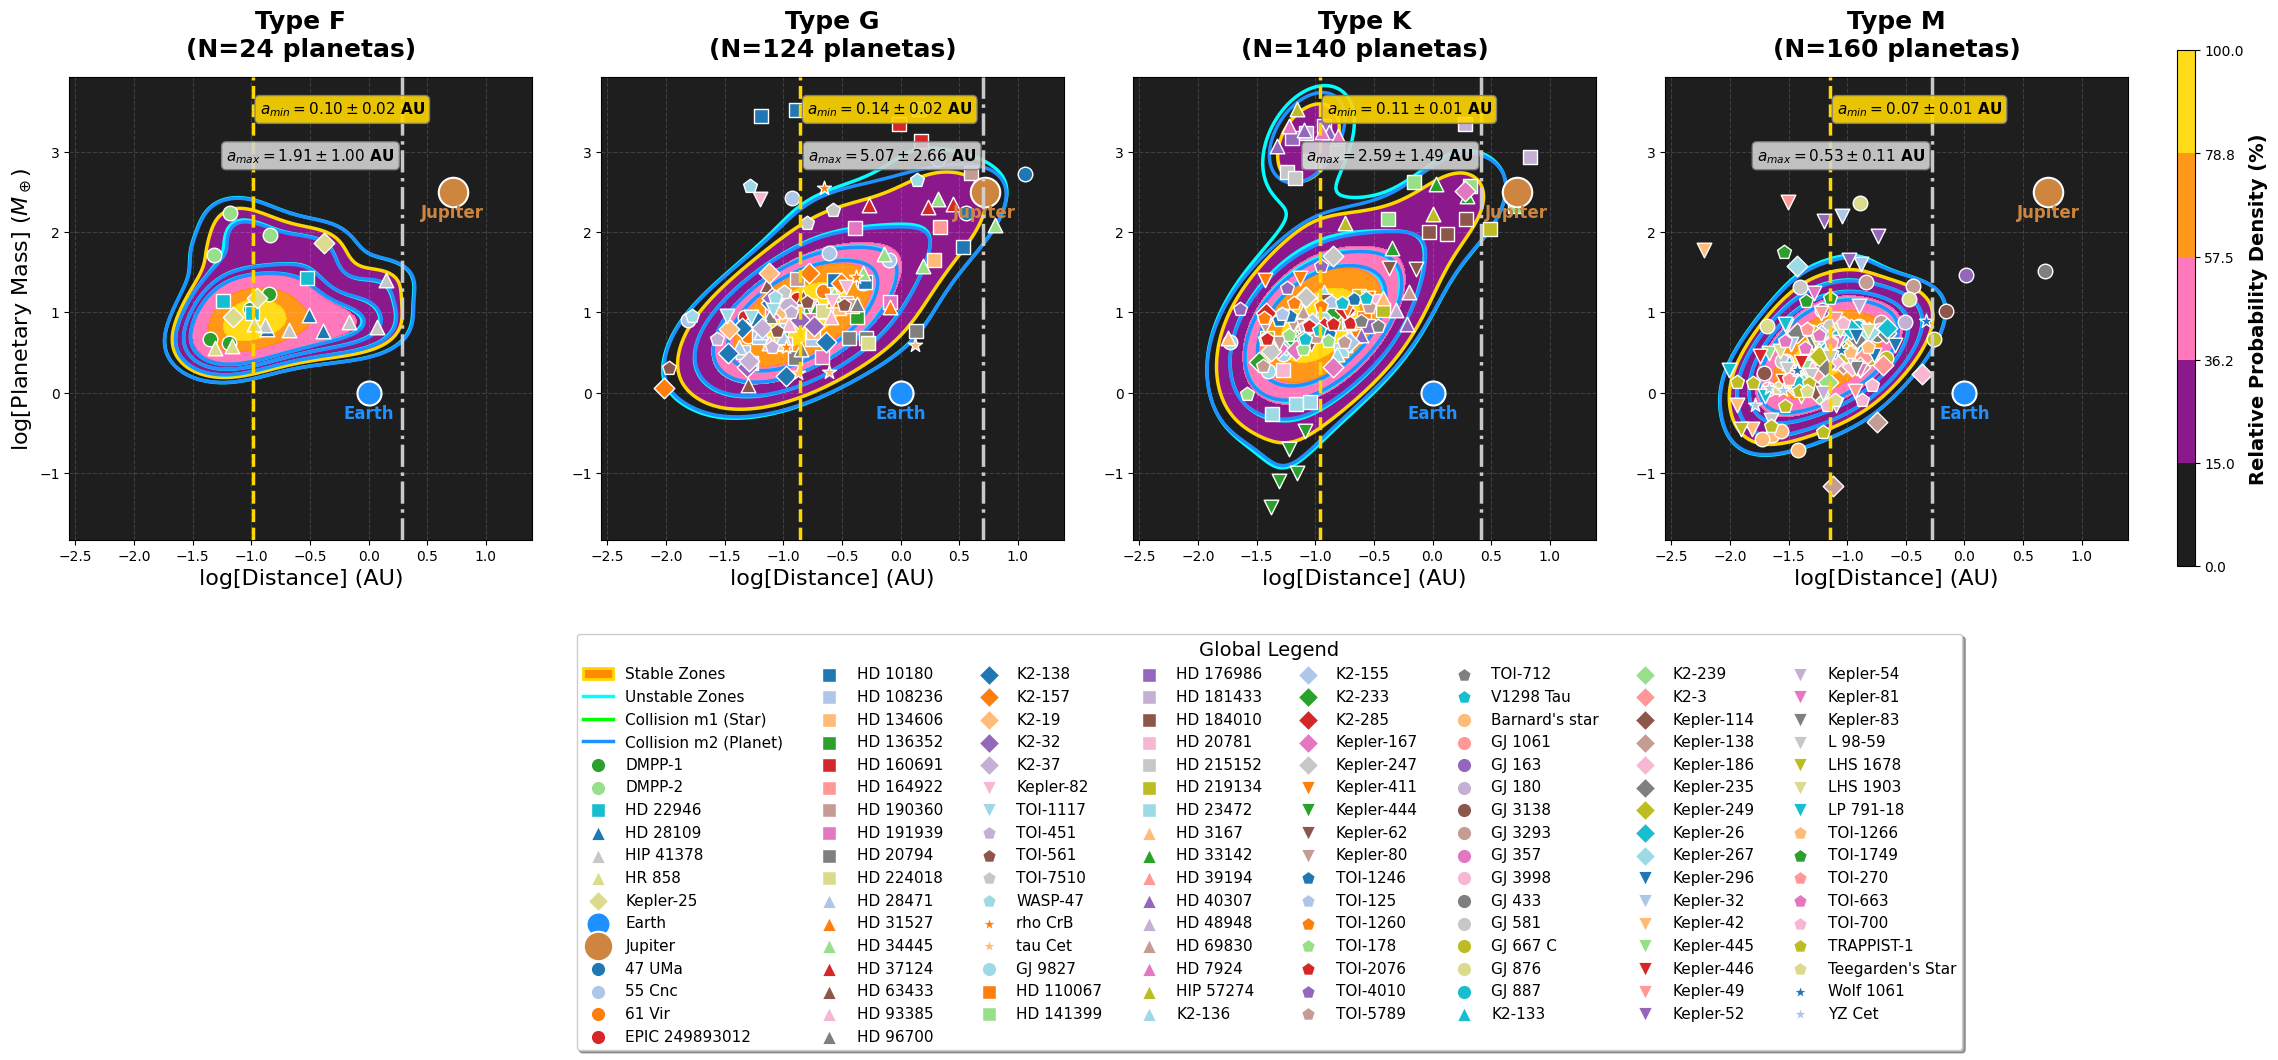


✅ Generación híbrida completada con éxito. Archivos ubicados en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F


In [11]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    print("Esperando selección de carpetas en las ventanas emergentes...")
    df_datos, DIRECTORIO_RAIZ = extraer_datos_personalizados()
    if not df_datos.empty:
        cantidades_encontradas = sorted(df_datos['Num_Planetas'].unique())
        print(f"\nDiagnóstico: hay sistemas con las siguientes cantidades de planetas: {cantidades_encontradas}")
        df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
        if not df_filtrado.empty:
            print(f"\nSe graficarán {len(df_filtrado)} planetas (sistemas de >= 3 planetas).")
            plot_islands_kde2d_combinado(df_filtrado, DIRECTORIO_RAIZ)
            print("\n✅ Generación híbrida completada con éxito. Archivos ubicados en:", DIRECTORIO_RAIZ)
        else:
            print("\nALERTA: No quedaron datos tras aplicar el filtro de >= 3 planetas.")
    else:
        print("\nNo se encontraron datos válidos, u operación cancelada por el usuario.")




Esperando selección de carpetas en las ventanas emergentes...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F (Tipo F)...
✅ Lectura completada. Se extrajeron datos de 24 planetas.

Diagnóstico: hay sistemas con las siguientes cantidades de planetas: [np.int64(3), np.int64(4), np.int64(5)]

Se graficarán 24 planetas (sistemas de >= 3 planetas).

Generando Mapas de Contornos 2D KDE Híbridos por Multiplicidad...


Generando paneles 2D: 100%|██████████| 3/3 [01:02<00:00, 20.73s/panel]



🎯 RESUMEN DE PROBABILIDAD ORBITAL Y LÍMITES MÁXIMOS
[3-Planet Systems]
  - Óptimo (Pico)          -> Distancia (a_min):   0.09 ± 0.03 AU
  - Zona Amarilla (>78.7%) -> Límite Máx (a_max):    nan AU
  - Zona Naranja  (>57.5%) -> Límite Máx (a_max):    nan AU
  - Zona Rosada   (>36.2%) -> Límite Máx (a_max):    nan AU
  - Zona Morada   (>15.0%) -> Límite Máx (a_max):    nan ± 0.18 AU
  - Unstable Zones         -> Límite Máx (a_max):   0.79 ± 0.19 AU
  - Collision m2 (Planet)  -> Límite Máx (a_max):   0.79 ± 0.20 AU
------------------------------------------------------------
[4-Planet Systems]
  - Óptimo (Pico)          -> Distancia (a_min):   0.12 ± 0.05 AU
  - Zona Amarilla (>78.7%) -> Límite Máx (a_max):    nan AU
  - Zona Naranja  (>57.5%) -> Límite Máx (a_max):    nan AU
  - Zona Rosada   (>36.2%) -> Límite Máx (a_max):    nan AU
  - Zona Morada   (>15.0%) -> Límite Máx (a_max):    nan ± 0.05 AU
  - Unstable Zones         -> Límite Máx (a_max):   0.25 ± 0.05 AU
  - Collision m2 (Pla

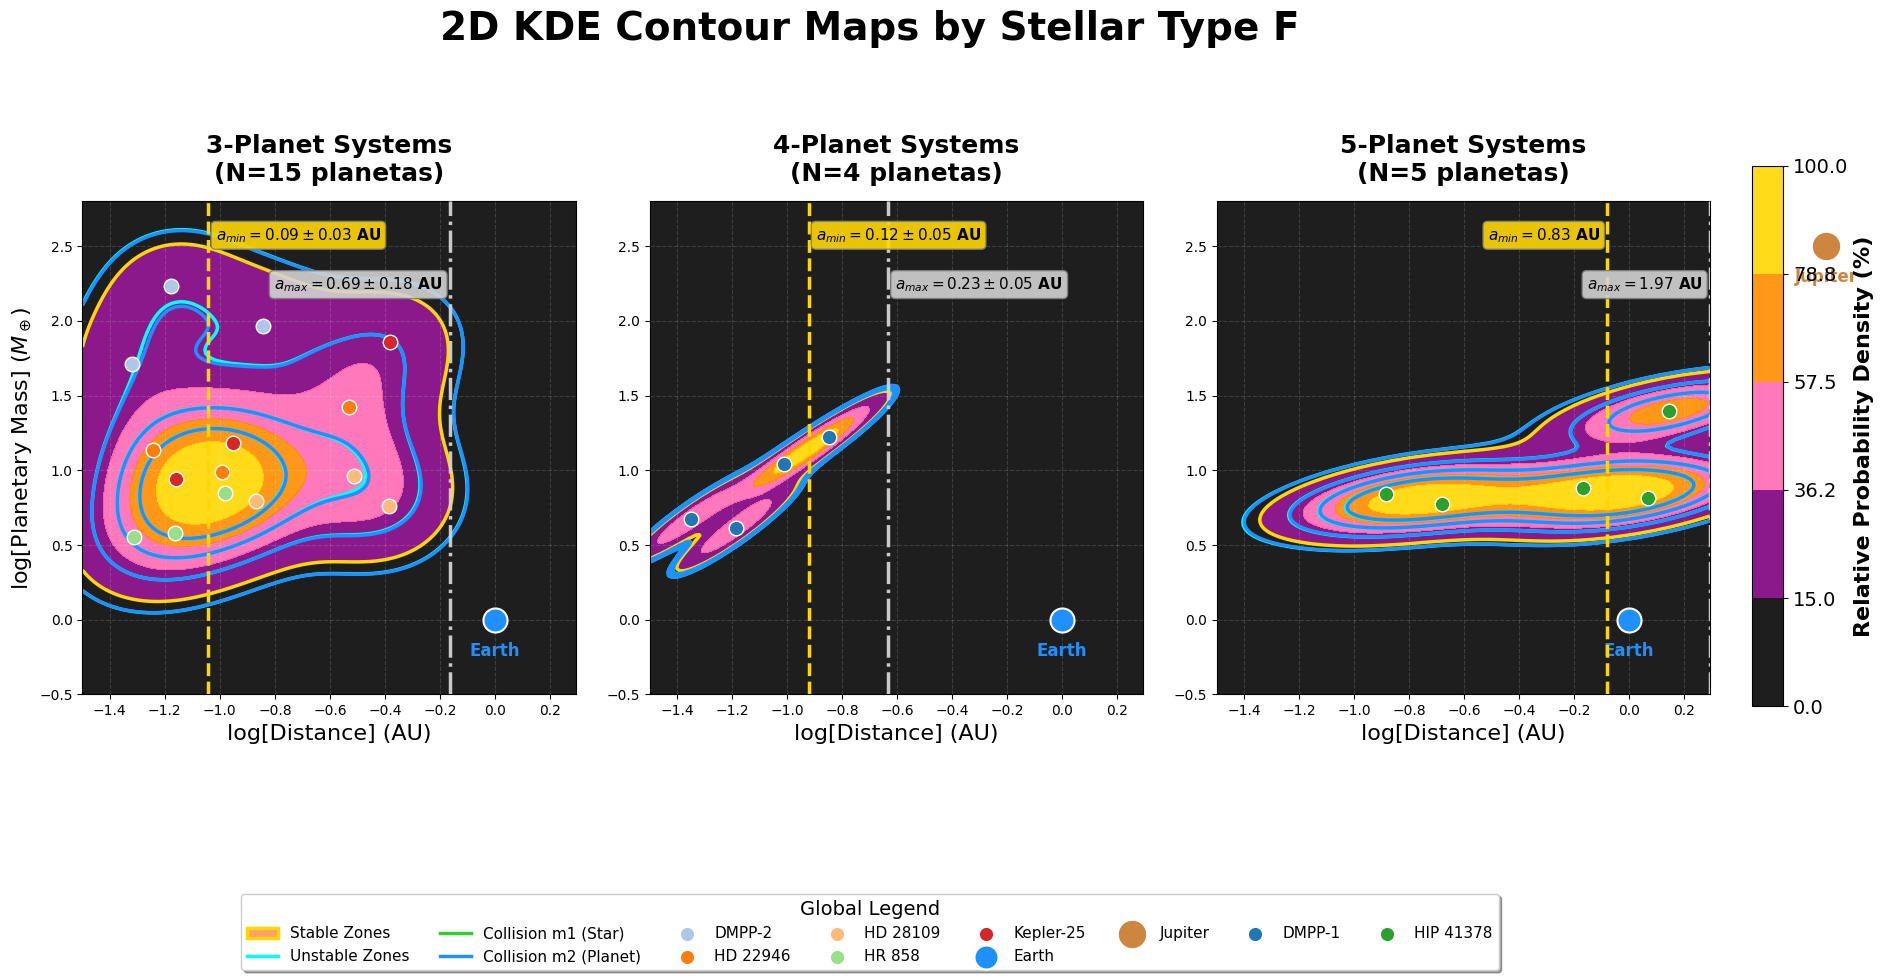


✅ Generación híbrida completada con éxito. Archivos ubicados en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F


In [14]:
if __name__ == "__main__":
    print("Esperando selección de carpetas en las ventanas emergentes...")
    df_datos, DIRECTORIO_RAIZ = extraer_datos_personalizados()
    
    if not df_datos.empty:
        cantidades_encontradas = sorted(df_datos['Num_Planetas'].unique())
        print(f"\nDiagnóstico: hay sistemas con las siguientes cantidades de planetas: {cantidades_encontradas}")
        df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
        
        if not df_filtrado.empty:
            print(f"\nSe graficarán {len(df_filtrado)} planetas (sistemas de >= 3 planetas).")
            # Llamamos a la función principal que hace la magia de Bootstrap, KDE Híbrido y el Colorbar global
            plot_islands_por_multiplicidad(df_filtrado, DIRECTORIO_RAIZ)
            print("\n✅ Generación híbrida completada con éxito. Archivos ubicados en:", DIRECTORIO_RAIZ)
        else:
            print("\nALERTA: No quedaron datos tras aplicar el filtro de >= 3 planetas.")
    else:
        print("\nNo se encontraron datos válidos, u operación cancelada por el usuario.")

Esperando selección de carpetas en las ventanas emergentes...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F (Tipo F)...
✅ Lectura completada. Se extrajeron datos de 24 planetas.

Diagnóstico: hay sistemas con las siguientes cantidades de planetas: [np.int64(3), np.int64(4), np.int64(5)]

Se graficarán 24 planetas (sistemas de >= 3 planetas).

Generando Mapas de Contornos 2D...


Generando paneles 2D: 100%|██████████| 3/3 [00:00<00:00, 14.46panel/s]



🎯 RESUMEN DE a_max POR NIVELES DE DENSIDAD

[Panel: 3-Planet Systems]
 -> Límite al  15.0% de densidad: a_max =   0.69 AU
 -> Límite al  36.2% de densidad: a_max =   0.46 AU
 -> Límite al  57.5% de densidad: a_max =   0.20 AU
 -> Límite al  78.8% de densidad: a_max =   0.14 AU
 -> Límite al 100.0% de densidad: a_max =   0.09 AU

[Panel: 4-Planet Systems]
 -> Límite al  15.0% de densidad: a_max =   0.23 AU
 -> Límite al  36.2% de densidad: a_max =   0.19 AU
 -> Límite al  57.5% de densidad: a_max =   0.17 AU
 -> Límite al  78.8% de densidad: a_max =   0.15 AU
 -> Límite al 100.0% de densidad: a_max =   0.11 AU

[Panel: 5-Planet Systems]
 -> Límite al  15.0% de densidad: a_max =   3.96 AU
 -> Límite al  36.2% de densidad: a_max =   2.75 AU
 -> Límite al  57.5% de densidad: a_max =   1.92 AU
 -> Límite al  78.8% de densidad: a_max =   1.43 AU
 -> Límite al 100.0% de densidad: a_max =   0.83 AU


Gráfico guardado en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Res

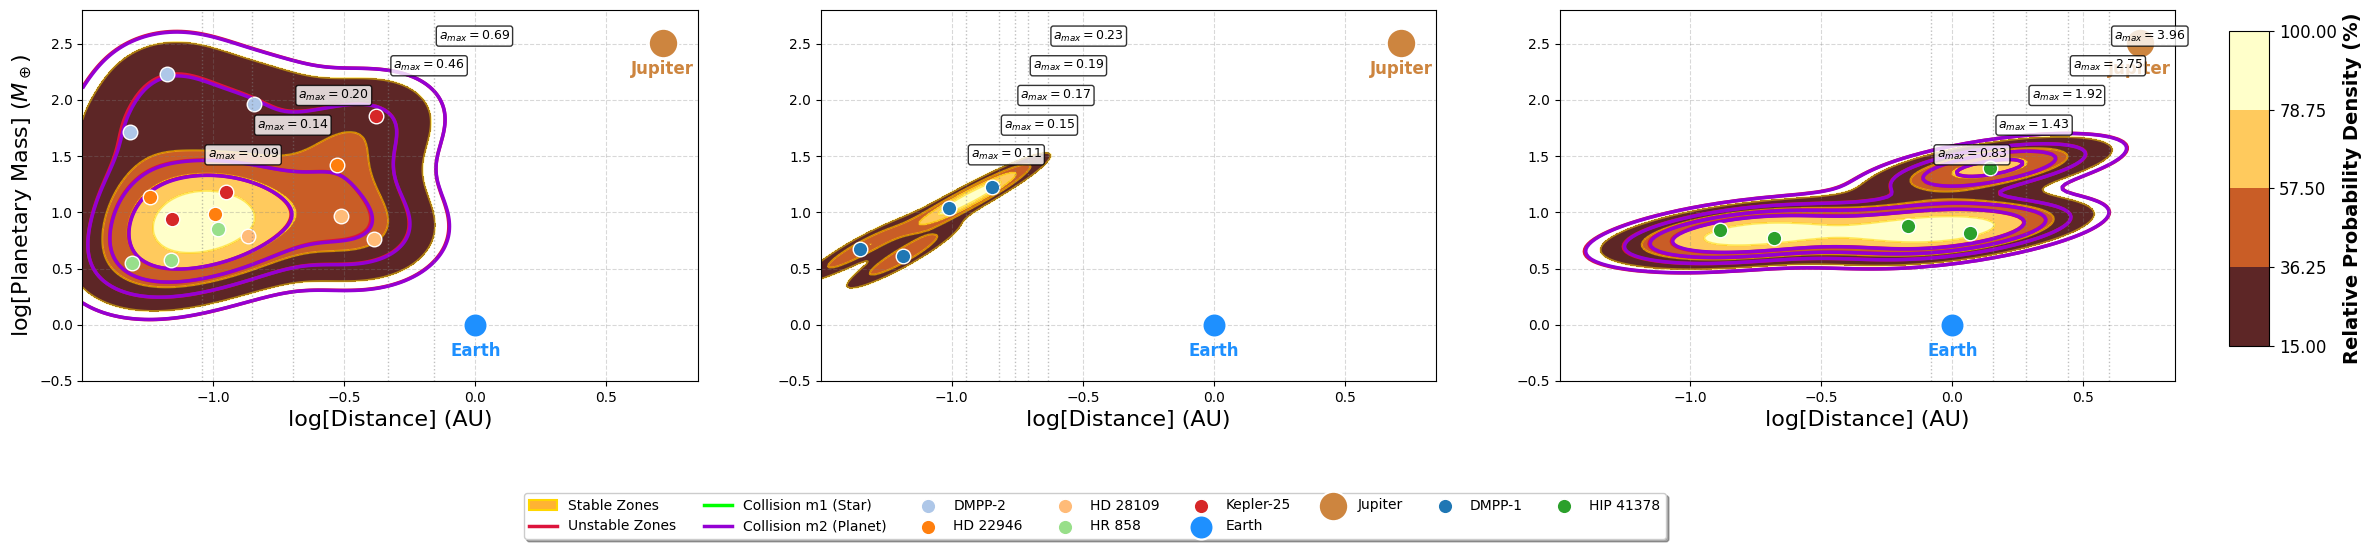


✅ Generación híbrida completada con éxito. Archivos ubicados en: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F


In [11]:
if __name__ == "__main__":
    print("Esperando selección de carpetas en las ventanas emergentes...")
    df_datos, DIRECTORIO_RAIZ = extraer_datos_personalizados()
    
    if not df_datos.empty:
        cantidades_encontradas = sorted(df_datos['Num_Planetas'].unique())
        print(f"\nDiagnóstico: hay sistemas con las siguientes cantidades de planetas: {cantidades_encontradas}")
        df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
        
        if not df_filtrado.empty:
            print(f"\nSe graficarán {len(df_filtrado)} planetas (sistemas de >= 3 planetas).")
            # Llamamos a la NUEVA función principal
            plot_islands_por_multiplicidad(df_filtrado, DIRECTORIO_RAIZ)
            print("\n✅ Generación híbrida completada con éxito. Archivos ubicados en:", DIRECTORIO_RAIZ)
        else:
            print("\nALERTA: No quedaron datos tras aplicar el filtro de >= 3 planetas.")
    else:
        print("\nNo se encontraron datos válidos, u operación cancelada por el usuario.")
